In [ ]:
"""
STEP 1: Fit Bass diffusion parameters (p, q) for every historical product
from its actual observed weekly_rx curve.

m (market potential) is FIXED, not fit, since it's directly computable:

    m = addressable_population * estimated_penetration

Only p (innovation rate) and q (imitation rate) are estimated via
nonlinear least squares against the real 52-week curve.

Output:
    bass_final.csv = bass_extended_150.csv + [m, p_fit, q_fit, fit_r2]
"""

import pandas as pd
import numpy as np
from scipy.optimize import curve_fit


# ============================================================
# LOAD DATA
# ============================================================

bass = pd.read_csv("bass_final.csv")
weekly = pd.read_csv("weekly_rx_final.csv")


# ============================================================
# CALCULATE M
# ============================================================

bass["m"] = (
    bass["addressable_population"]
    *
    bass["estimated_penetration"]
)


# ============================================================
# BASS WEEKLY CURVE
# ============================================================

def bass_weekly_curve(t, p, q, m):
    """
    Bass model weekly adoption count.

    t = week number
    p = innovation coefficient
    q = imitation coefficient
    m = market potential
    """

    F = (
        1 - np.exp(-(p + q) * t)
    ) / (
        1 +
        (q / p) *
        np.exp(-(p + q) * t)
    )

    F_prev = (
        np.concatenate([[0], F[:-1]])
        if len(t) > 1
        else np.array([0.0])
    )

    return m * (F - F_prev)


# ============================================================
# FIT P AND Q FOR EACH PRODUCT
# ============================================================

records = []
failed = []


for _, row in bass.iterrows():

    pid = row["product_id"]

    m_fixed = row["m"]

    sub = (
        weekly[
            weekly["product_id"] == pid
        ]
        .sort_values("week_since_launch")
    )

    t_obs = (
        sub["week_since_launch"]
        .values
        .astype(float)
    )

    y_obs = (
        sub["weekly_rx"]
        .values
        .astype(float)
    )


    def model(t, p, q):

        return bass_weekly_curve(
            t,
            p,
            q,
            m_fixed
        )


    try:

        popt, _ = curve_fit(
            model,
            t_obs,
            y_obs,

            p0=[
                0.03,
                0.3
            ],

            bounds=(
                [
                    0.0001,
                    0.001
                ],
                [
                    0.5,
                    3.0
                ]
            ),

            maxfev=5000
        )


        p_fit, q_fit = popt


        pred = model(
            t_obs,
            p_fit,
            q_fit
        )


        ss_res = np.sum(
            (y_obs - pred) ** 2
        )

        ss_tot = np.sum(
            (y_obs - y_obs.mean()) ** 2
        )


        r2 = (
            1 - ss_res / ss_tot
            if ss_tot > 0
            else np.nan
        )


    except Exception as e:

        p_fit = np.nan
        q_fit = np.nan
        r2 = np.nan

        failed.append(
            (
                pid,
                str(e)
            )
        )


    records.append(
        {
            "product_id": pid,
            "p_fit": p_fit,
            "q_fit": q_fit,
            "fit_r2": r2
        }
    )


# ============================================================
# MERGE RESULTS
# ============================================================

fit_df = pd.DataFrame(records)


bass_final = bass.merge(
    fit_df,
    on="product_id"
)


# ============================================================
# SAVE
# ============================================================

bass_final.to_csv(
    "bass_final.csv",
    index=False
)


# ============================================================
# REPORT
# ============================================================

print(
    f"Fitted "
    f"{bass_final['p_fit'].notna().sum()} "
    f"/ "
    f"{len(bass_final)} "
    f"products"
)

print(
    f"Failed: {len(failed)}"
)

if failed:

    print(failed)


print()

print("Fit quality (R²) summary:")

print(
    bass_final["fit_r2"].describe()
)

print()

print("Saved -> bass_final.csv")

print(
    bass_final[
        [
            "product_id",
            "m",
            "p_fit",
            "q_fit",
            "fit_r2"
        ]
    ].head()
)

Fitted 150 / 150 products
Failed: 0

Fit quality (R²) summary:
count    150.000000
mean       0.895230
std        0.133706
min        0.215302
25%        0.890680
50%        0.941967
75%        0.966168
max        0.984371
Name: fit_r2, dtype: float64

Saved -> bass_final.csv
  product_id          m     p_fit     q_fit    fit_r2
0       P001  46951.416  0.020760  0.160984  0.960114
1       P002   9828.692  0.036677  0.144763  0.976945
2       P003   4420.034  0.008251  0.095331  0.817229
3       P004  42388.920  0.028233  0.177247  0.952215
4       P005   8252.164  0.001710  0.048265  0.643072


In [ ]:
"""
STEP 2: Train ML models that predict Bass parameters p and q
from a product's PRE-LAUNCH features.

Two separate models:

    p ~ marketing_awareness, launch_strength,
        physician_awareness, competition_level,
        market_access_level

    q ~ clinical_evidence_strength,
        treatment_familiarity,
        competition_level,
        market_access_level

Model:
    Ridge regression on log(p), log(q)

Output:
    model_p.joblib
    model_q.joblib
"""

import pandas as pd
import numpy as np

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import joblib


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(
    "bass_final.csv"
)


# ============================================================
# FEATURES
# ============================================================

P_FEATURES = [
    "marketing_awareness",
    "launch_strength",
    "physician_awareness",
    "competition_level",
    "market_access_level"
]


Q_FEATURES = [
    "clinical_evidence_strength",
    "treatment_familiarity",
    "competition_level",
    "market_access_level"
]


# ============================================================
# PREPARE DATA
# ============================================================

Xp = df[
    P_FEATURES
].values

Xq = df[
    Q_FEATURES
].values


log_p = np.log(
    df["p_fit"].values
)

log_q = np.log(
    df["q_fit"].values
)


# ============================================================
# SCALE FEATURES
# ============================================================

scaler_p = (
    StandardScaler()
    .fit(Xp)
)

scaler_q = (
    StandardScaler()
    .fit(Xq)
)


# ============================================================
# TRAIN MODELS
# ============================================================

model_p = Ridge(
    alpha=5.0
).fit(
    scaler_p.transform(Xp),
    log_p
)


model_q = Ridge(
    alpha=5.0
).fit(
    scaler_q.transform(Xq),
    log_q
)


# ============================================================
# SAVE MODELS
# ============================================================

joblib.dump(
    {
        "model": model_p,
        "scaler": scaler_p,
        "features": P_FEATURES
    },
    "model_p.joblib"
)


joblib.dump(
    {
        "model": model_q,
        "scaler": scaler_q,
        "features": Q_FEATURES
    },
    "model_q.joblib"
)


print(
    "Saved model_p.joblib and model_q.joblib"
)


# ============================================================
# COEFFICIENTS
# ============================================================

print()

print(
    "Model coefficients "
    "(standardized features, log-scale target):"
)


print(
    "p-model:"
)

for f, c in zip(
    P_FEATURES,
    model_p.coef_
):

    print(
        f"   {f:25s} "
        f"{c:+.4f}"
    )


print(
    "q-model:"
)

for f, c in zip(
    Q_FEATURES,
    model_q.coef_
):

    print(
        f"   {f:25s} "
        f"{c:+.4f}"
    )


# ============================================================
# LEAVE-ONE-OUT VALIDATION
# ============================================================

n = len(df)

curve_corrs = []


weekly = pd.read_csv(
    "weekly_rx_final.csv"
)


ids = df[
    "product_id"
].tolist()


curve_pivot = (
    weekly
    .pivot(
        index="product_id",
        columns="week_since_launch",
        values="weekly_rx"
    )
    .loc[ids]
)


curve_shape_actual = (
    curve_pivot.values
    /
    curve_pivot.values.sum(
        axis=1,
        keepdims=True
    )
)


m_vals = df[
    "m"
].values


# ============================================================
# BASS FUNCTION FOR VALIDATION
# ============================================================

def bass_weekly(
    p,
    q,
    m,
    weeks=52
):

    t = np.arange(
        1,
        weeks + 1
    )

    F = (
        1 -
        np.exp(
            -(p + q) * t
        )
    ) / (
        1 +
        (q / p) *
        np.exp(
            -(p + q) * t
        )
    )


    Fp = np.concatenate(
        [
            [0],
            F[:-1]
        ]
    )


    return m * (
        F - Fp
    )


# ============================================================
# LOO LOOP
# ============================================================

for i in range(n):

    tr = [
        j
        for j in range(n)
        if j != i
    ]


    sp = (
        StandardScaler()
        .fit(Xp[tr])
    )

    sq = (
        StandardScaler()
        .fit(Xq[tr])
    )


    mp = Ridge(
        alpha=5.0
    ).fit(
        sp.transform(Xp[tr]),
        log_p[tr]
    )


    mq = Ridge(
        alpha=5.0
    ).fit(
        sq.transform(Xq[tr]),
        log_q[tr]
    )


    p_pred = np.exp(
        mp.predict(
            sp.transform(
                Xp[i:i + 1]
            )
        )
    )[0]


    q_pred = np.exp(
        mq.predict(
            sq.transform(
                Xq[i:i + 1]
            )
        )
    )[0]


    curve_pred = bass_weekly(
        p_pred,
        q_pred,
        m_vals[i]
    )


    curve_corrs.append(
        np.corrcoef(
            curve_pred /
            curve_pred.sum(),

            curve_shape_actual[i]
        )[0, 1]
    )


# ============================================================
# VALIDATION RESULT
# ============================================================

print()

print(
    "Leave-one-out validation:"
)

print(
    f"Mean curve correlation = "
    f"{np.mean(curve_corrs):.4f}"
)

print(
    f"Median = "
    f"{np.median(curve_corrs):.4f}"
)

Saved model_p.joblib and model_q.joblib

Model coefficients (standardized features, log-scale target):
p-model:
   marketing_awareness       +0.6641
   launch_strength           +0.4946
   physician_awareness       +0.3024
   competition_level         +0.0214
   market_access_level       +0.0699
q-model:
   clinical_evidence_strength +0.3195
   treatment_familiarity     +0.3061
   competition_level         -0.0008
   market_access_level       +0.0042

Leave-one-out validation:
Mean curve correlation = 0.8565
Median = 0.9293


In [ ]:
!pip install gower


ANALOGS USED
P020       weight=0.461 similarity=1.000
P065       weight=0.272 similarity=0.591
P051       weight=0.267 similarity=0.579

BASS PARAMETERS
p_hat = 0.0199
q_hat = 0.1565
m_hat = 97414

52-WEEK HYBRID FORECAST
 week_since_launch  hybrid_forecast_rx  cumulative_hybrid_rx
                 1         2072.013038           2072.013038
                 2         2292.956108           4364.969146
                 3         2610.408392           6975.377538
                 4         2907.250709           9882.628247
                 5         3225.868609          13108.496855
                 6         3487.105549          16595.602404
                 7         3806.065973          20401.668377
                 8         4012.880482          24414.548858
                 9         4276.212312          28690.761170
                10         4466.182288          33156.943459
                11         4584.665166          37741.608624
                12         4596.541964       

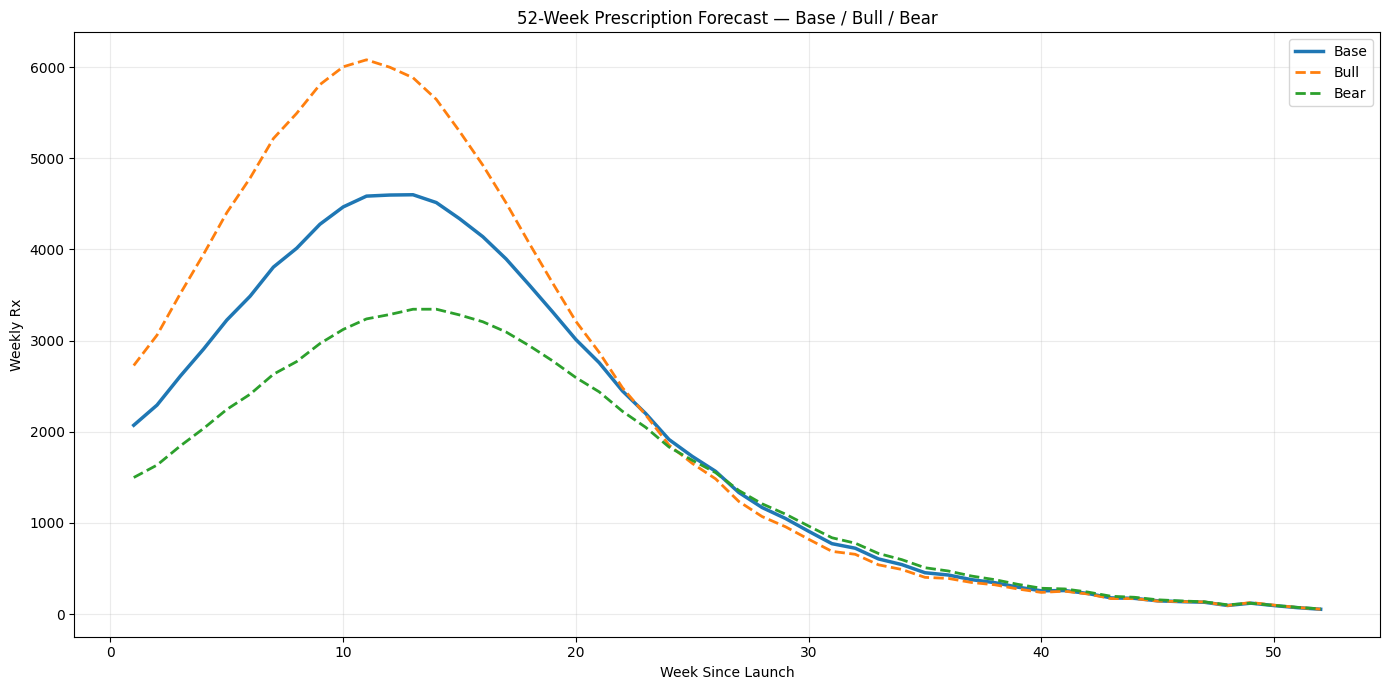

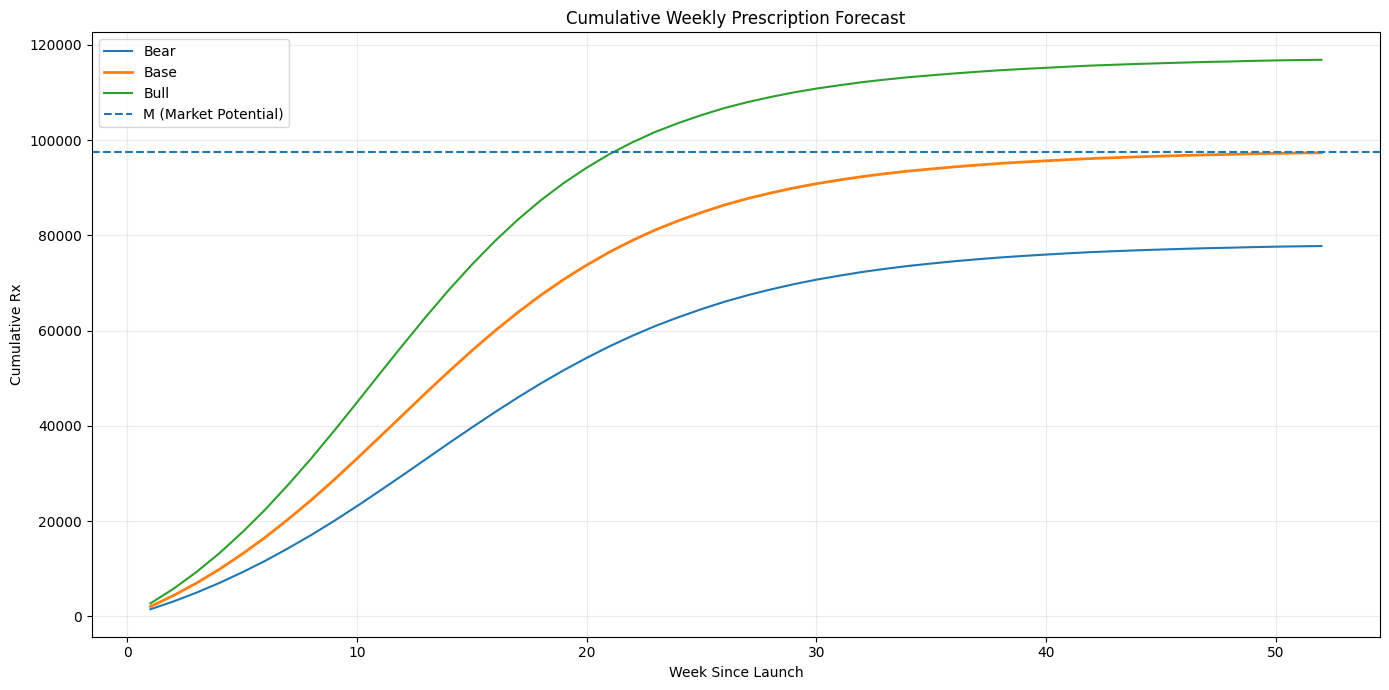


FILES SAVED
1. new_drug_weekly_forecast.csv
2. new_drug_monthly_forecast.csv
3. rx_forecast_weekly.png
4. rx_forecast_cumulative.png

Forecast completed successfully.


In [ ]:
#STEP 3
import pandas as pd
import numpy as np
import gower
import joblib
import matplotlib.pyplot as plt


# ============================================================
# 2. CONFIGURATION
# ============================================================

WEEKS = 52
TOP_K = 3

W_ANALOG = 0.10
W_BASS = 0.90


# ============================================================
# 3. SIMILARITY FEATURES
# ============================================================

FEATURES = [
    "therapeutic_area",
    "indication",
    "active_ingredient",
    "pharmacological_class",
    "mechanism_of_action",
    "route_of_administration",
    "target_population",
    "addressable_population",
    "competition_level",
    "relative_price_index",
    "market_access_level",
    "clinical_evidence_strength"
]


CATEGORICAL_FEATURES = [
    "therapeutic_area",
    "indication",
    "active_ingredient",
    "pharmacological_class",
    "mechanism_of_action",
    "route_of_administration",
    "target_population"
]


# ============================================================
# 4. LOAD DATA
# ============================================================

sim_df = pd.read_csv(
    "similarity+analog_features_final.csv"
)

bass_df = pd.read_csv(
    "bass_final.csv"
)

weekly_df = pd.read_csv(
    "weekly_rx_final.csv"
)


# ============================================================
# 5. LOAD TRAINED p AND q MODELS
# ============================================================

model_p_bundle = joblib.load(
    "model_p.joblib"
)

model_q_bundle = joblib.load(
    "model_q.joblib"
)


# ============================================================
# 6. BASS WEEKLY RX CURVE
# ============================================================

def bass_curve(p, q, m):

    t = np.arange(
        1,
        WEEKS + 1,
        dtype=float
    )

    p = max(
        float(p),
        1e-8
    )

    q = max(
        float(q),
        1e-8
    )

    m = float(m)

    # Cumulative Bass adoption fraction
    F = (
        1
        -
        np.exp(
            -(p + q) * t
        )
    ) / (
        1
        +
        (q / p)
        *
        np.exp(
            -(p + q) * t
        )
    )

    # Previous week's cumulative adoption
    F_previous = np.r_[
        0,
        F[:-1]
    ]

    # Weekly RX
    weekly_rx = m * (
        F - F_previous
    )

    return weekly_rx


# ============================================================
# 7. FIND TOP-K GOWER ANALOGS
# ============================================================

def get_top_analogs(
    new_drug,
    similarity_df,
    k=TOP_K
):

    # Combine historical products + new product
    new_row = pd.DataFrame([
        {
            feature: new_drug[feature]
            for feature in FEATURES
        }
    ])

    combined = pd.concat(
        [
            similarity_df[FEATURES],
            new_row
        ],
        ignore_index=True
    )

    # Tell Gower which columns are categorical
    categorical_mask = [
        feature in CATEGORICAL_FEATURES
        for feature in FEATURES
    ]

    # Gower distance
    distance_matrix = gower.gower_matrix(
        combined,
        cat_features=categorical_mask
    )

    # Convert distance → similarity
    similarity_matrix = (
        1 -
        distance_matrix
    )

    # Last row = new drug
    new_index = (
        len(combined) - 1
    )

    similarities = pd.Series(
        similarity_matrix[
            new_index,
            :-1
        ],
        index=similarity_df["product_id"]
    )

    # Top K
    top_k = similarities.sort_values(
        ascending=False
    ).head(k)

    # Similarity-based weights
    if top_k.sum() > 0:

        weights = (
            top_k /
            top_k.sum()
        )

    else:

        weights = pd.Series(
            1 / len(top_k),
            index=top_k.index
        )

    analog_list = []

    for product_id in top_k.index:

        analog_list.append(
            (
                product_id,
                float(
                    weights.loc[product_id]
                ),
                float(
                    top_k.loc[product_id]
                )
            )
        )

    return analog_list


# ============================================================
# 8. HISTORICAL ANALOG RX CURVE
# ============================================================

def analog_curve(
    new_drug,
    similarity_df,
    historical_weekly,
    total_rx,
    k=TOP_K
):

    # Find top analogs
    analog_list = get_top_analogs(
        new_drug,
        similarity_df,
        k
    )

    # Historical weekly RX matrix
    rx_pivot = historical_weekly.pivot(
        index="product_id",
        columns="week_since_launch",
        values="weekly_rx"
    )

    # Ensure exactly weeks 1–52
    rx_pivot = rx_pivot.reindex(
        columns=range(1, WEEKS + 1)
    )

    rx_pivot = rx_pivot.fillna(0)

    # Convert each historical curve
    # into a normalized shape
    curve_shapes = rx_pivot.div(
        rx_pivot.sum(axis=1).replace(
            0,
            np.nan
        ),
        axis=0
    ).fillna(0)

    # Weighted blended shape
    blended_shape = np.zeros(
        WEEKS
    )

    for (
        product_id,
        weight,
        similarity
    ) in analog_list:

        blended_shape += (
            float(weight)
            *
            curve_shapes.loc[
                product_id
            ].values
        )

    # Scale shape to new drug's
    # total RX
    analog_rx = (
        blended_shape
        *
        float(total_rx)
    )

    return (
        analog_rx,
        analog_list
    )


# ============================================================
# 9. NEW DRUG
# ============================================================

new_drug = {

    "product_id":
        "NEW_P020",

    # --------------------------------------------------------
    # Similarity / Analog Features
    # --------------------------------------------------------

    "therapeutic_area":
        "Cardiology",

    "indication":
        "Atrial Fibrillation",

    "active_ingredient":
        "Apixaban",

    "pharmacological_class":
        "Anticoagulant (Factor Xa Inhibitor)",

    "mechanism_of_action":
        "Directly inhibits Factor Xa, reducing thrombin generation",

    "route_of_administration":
        "Oral",

    "target_population":
        "Adult",

    "addressable_population":
        649430,

    "competition_level":
        6.1,

    "relative_price_index":
        1.33,

    "market_access_level":
        1.4,

    "clinical_evidence_strength":
        4.4,

    # --------------------------------------------------------
    # Bass / Pre-launch Features
    # --------------------------------------------------------

    "estimated_penetration":
        0.15,

    "marketing_awareness":
        7.0,

    "launch_strength":
        7.0,

    "physician_awareness":
        6.0,

    "treatment_familiarity":
        8.0
}


# ============================================================
# 10. PREDICT p
# ============================================================

p_features = (
    model_p_bundle["features"]
)

p_model = (
    model_p_bundle["model"]
)

p_scaler = (
    model_p_bundle["scaler"]
)

X_p_new = np.array([
    [
        new_drug[feature]
        for feature in p_features
    ]
], dtype=float)

p_hat = float(
    np.exp(
        p_model.predict(
            p_scaler.transform(
                X_p_new
            )
        )[0]
    )
)


# ============================================================
# 11. PREDICT q
# ============================================================

q_features = (
    model_q_bundle["features"]
)

q_model = (
    model_q_bundle["model"]
)

q_scaler = (
    model_q_bundle["scaler"]
)

X_q_new = np.array([
    [
        new_drug[feature]
        for feature in q_features
    ]
], dtype=float)

q_hat = float(
    np.exp(
        q_model.predict(
            q_scaler.transform(
                X_q_new
            )
        )[0]
    )
)


# ============================================================
# 12. CALCULATE M
# ============================================================

m_hat = (
    new_drug[
        "addressable_population"
    ]
    *
    new_drug[
        "estimated_penetration"
    ]
)


# ============================================================
# 13. BASE BASS FORECAST
# ============================================================

bass_base = bass_curve(
    p_hat,
    q_hat,
    m_hat
)


# ============================================================
# 14. BASE ANALOG FORECAST
# ============================================================

analog_base, analogs_used = analog_curve(
    new_drug,
    sim_df,
    weekly_df,
    m_hat,
    TOP_K
)


# ============================================================
# 15. BASE HYBRID
# ============================================================

base = (
    W_ANALOG * analog_base
    +
    W_BASS * bass_base
)


# ============================================================
# 16. BULL SCENARIO
# ============================================================

bull_p = (
    p_hat * 1.10
)

bull_q = (
    q_hat * 1.10
)

bull_m = (
    m_hat * 1.20
)

bass_bull = bass_curve(
    bull_p,
    bull_q,
    bull_m
)

analog_bull, _ = analog_curve(
    new_drug,
    sim_df,
    weekly_df,
    bass_bull.sum(),
    TOP_K
)

bull = (
    W_ANALOG * analog_bull
    +
    W_BASS * bass_bull
)


# ============================================================
# 17. BEAR SCENARIO
# ============================================================

bear_p = (
    p_hat * 0.90
)

bear_q = (
    q_hat * 0.90
)

bear_m = (
    m_hat * 0.80
)

bass_bear = bass_curve(
    bear_p,
    bear_q,
    bear_m
)

analog_bear, _ = analog_curve(
    new_drug,
    sim_df,
    weekly_df,
    bass_bear.sum(),
    TOP_K
)

bear = (
    W_ANALOG * analog_bear
    +
    W_BASS * bass_bear
)


# ============================================================
# 18. WEEKLY OUTPUT DATAFRAME
# ============================================================

weeks = np.arange(
    1,
    WEEKS + 1
)

forecast_df = pd.DataFrame({

    "week_since_launch":
        weeks,

    "analog_forecast_rx":
        analog_base,

    "bass_forecast_rx":
        bass_base,

    "hybrid_forecast_rx":
        base,

    "bull_hybrid_rx":
        bull,

    "base_hybrid_rx":
        base,

    "bear_hybrid_rx":
        bear
})


# ============================================================
# 19. CUMULATIVE WEEKLY RX
# ============================================================

forecast_df[
    "cumulative_analog_rx"
] = (
    forecast_df[
        "analog_forecast_rx"
    ].cumsum()
)

forecast_df[
    "cumulative_bass_rx"
] = (
    forecast_df[
        "bass_forecast_rx"
    ].cumsum()
)

forecast_df[
    "cumulative_hybrid_rx"
] = (
    forecast_df[
        "hybrid_forecast_rx"
    ].cumsum()
)

forecast_df[
    "cumulative_bull_rx"
] = (
    forecast_df[
        "bull_hybrid_rx"
    ].cumsum()
)

forecast_df[
    "cumulative_base_rx"
] = (
    forecast_df[
        "base_hybrid_rx"
    ].cumsum()
)

forecast_df[
    "cumulative_bear_rx"
] = (
    forecast_df[
        "bear_hybrid_rx"
    ].cumsum()
)


# ============================================================
# 20. SAVE WEEKLY CSV
# ============================================================

forecast_df.to_csv(
    "new_drug_weekly_forecast.csv",
    index=False
)


# ============================================================
# 21. WEEKLY → MONTHLY
# ============================================================

def weekly_to_monthly(
    weekly_curve
):

    monthly = []

    for month in range(12):

        start = (
            month * 4
        )

        end = min(
            start + 4,
            len(weekly_curve)
        )

        monthly.append(
            weekly_curve[
                start:end
            ].sum()
        )

    return np.array(
        monthly
    )


# ============================================================
# 22. MONTHLY FORECAST
# ============================================================

monthly_df = pd.DataFrame({

    "month":
        np.arange(1, 13),

    "hybrid_rx":
        weekly_to_monthly(
            base
        ),

    "bull_hybrid_rx":
        weekly_to_monthly(
            bull
        ),

    "base_hybrid_rx":
        weekly_to_monthly(
            base
        ),

    "bear_hybrid_rx":
        weekly_to_monthly(
            bear
        )
})


# ============================================================
# 23. CUMULATIVE MONTHLY RX
# ============================================================

monthly_df[
    "cumulative_hybrid_rx"
] = monthly_df[
    "hybrid_rx"
].cumsum()

monthly_df[
    "cumulative_bull_rx"
] = monthly_df[
    "bull_hybrid_rx"
].cumsum()

monthly_df[
    "cumulative_base_rx"
] = monthly_df[
    "base_hybrid_rx"
].cumsum()

monthly_df[
    "cumulative_bear_rx"
] = monthly_df[
    "bear_hybrid_rx"
].cumsum()


# ============================================================
# 24. SAVE MONTHLY CSV
# ============================================================

monthly_df.to_csv(
    "new_drug_monthly_forecast.csv",
    index=False
)


# ============================================================
# 25. PRINT ANALOGS
# ============================================================

print()
print("==========================================")
print("ANALOGS USED")
print("==========================================")

for (
    product_id,
    weight,
    similarity
) in analogs_used:

    print(
        f"{product_id:<10} "
        f"weight={weight:.3f} "
        f"similarity={similarity:.3f}"
    )


# ============================================================
# 26. PRINT BASS PARAMETERS
# ============================================================

print()
print("==========================================")
print("BASS PARAMETERS")
print("==========================================")

print(
    f"p_hat = {p_hat:.4f}"
)

print(
    f"q_hat = {q_hat:.4f}"
)

print(
    f"m_hat = {m_hat:.0f}"
)


# ============================================================
# 27. PRINT 52-WEEK FORECAST
# ============================================================

print()
print("==========================================")
print("52-WEEK HYBRID FORECAST")
print("==========================================")

print(
    forecast_df[
        [
            "week_since_launch",
            "hybrid_forecast_rx",
            "cumulative_hybrid_rx"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 28. PRINT MONTHLY FORECAST
# ============================================================

print()
print("==========================================")
print("12-MONTH HYBRID FORECAST")
print("==========================================")

print(
    monthly_df[
        [
            "month",
            "hybrid_rx",
            "cumulative_hybrid_rx"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 29. FORECAST TOTALS
# ============================================================

print()
print("==========================================")
print("FORECAST TOTALS")
print("==========================================")


print(
    f"52-week Bull Rx   : "
    f"{bull.sum():,.0f}"
)

print(
    f"52-week Base Rx   : "
    f"{base.sum():,.0f}"
)

print(
    f"52-week Bear Rx   : "
    f"{bear.sum():,.0f}"
)


# ============================================================
# 30. WEEKLY RX GRAPH
# ============================================================

plt.figure(
    figsize=(14, 7)
)

plt.plot(
    weeks,
    base,
    label="Base",
    linewidth=2.5
)

plt.plot(
    weeks,
    bull,
    "--",
    label="Bull",
    linewidth=2
)

plt.plot(
    weeks,
    bear,
    "--",
    label="Bear",
    linewidth=2
)

plt.xlabel(
    "Week Since Launch"
)

plt.ylabel(
    "Weekly Rx"
)

plt.title(
    "52-Week Prescription Forecast — Base / Bull / Bear"
)

plt.grid(
    True,
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "rx_forecast_weekly.png",
    dpi=180
)

plt.show()


# ============================================================
# 31. CUMULATIVE RX GRAPH
# ============================================================

plt.figure(
    figsize=(14, 7)
)

plt.plot(
    weeks,
    forecast_df[
        "cumulative_bear_rx"
    ],
    label="Bear"
)

plt.plot(
    weeks,
    forecast_df[
        "cumulative_base_rx"
    ],
    label="Base",
    linewidth=2
)

plt.plot(
    weeks,
    forecast_df[
        "cumulative_bull_rx"
    ],
    label="Bull"
)

# M reference
plt.axhline(
    m_hat,
    linestyle="--",
    label="M (Market Potential)"
)

plt.xlabel(
    "Week Since Launch"
)

plt.ylabel(
    "Cumulative Rx"
)

plt.title(
    "Cumulative Weekly Prescription Forecast"
)

plt.grid(
    True,
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "rx_forecast_cumulative.png",
    dpi=180
)

plt.show()


# ============================================================
# 32. FINAL SAVED FILES
# ============================================================

print()
print("==========================================")
print("FILES SAVED")
print("==========================================")

print(
    "1. new_drug_weekly_forecast.csv"
)

print(
    "2. new_drug_monthly_forecast.csv"
)

print(
    "3. rx_forecast_weekly.png"
)

print(
    "4. rx_forecast_cumulative.png"
)

print()
print("Forecast completed successfully.")

In [ ]:
"""
ANALOG + BASS HYBRID WEIGHT VALIDATION
---------------------------------------

Tests:
    0% Analog / 100% Bass
    10% Analog / 90% Bass
    ...
    100% Analog / 0% Bass

Uses Leave-One-Out (LOO) validation.

Metrics:
    - Curve Correlation          ↑ higher is better
    - MAE                        ↓ lower is better
    - RMSE                       ↓ lower is better
    - MAPE                       ↓ lower is better
    - sMAPE                      ↓ lower is better
    - WAPE                       ↓ lower is better
    - 52-week cumulative error   ↓ lower is better
    - Peak-week error            ↓ lower is better

IMPORTANT:
    During LOO, the held-out product is NOT allowed to be
    selected as its own analog.
"""

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. LOAD DATA
# ============================================================

bass_df = pd.read_csv("bass_final.csv")
weekly = pd.read_csv("weekly_rx_final.csv")
sim_df = pd.read_csv("similarity+analog_features_final.csv")


# ============================================================
# 2. FEATURES FOR BASS ML
# ============================================================

P_FEATURES = [
    "marketing_awareness",
    "launch_strength",
    "physician_awareness",
    "competition_level",
    "market_access_level"
]

Q_FEATURES = [
    "clinical_evidence_strength",
    "treatment_familiarity",
    "competition_level",
    "market_access_level"
]


Xp = bass_df[P_FEATURES].values
Xq = bass_df[Q_FEATURES].values

log_p = np.log(bass_df["p_fit"].values)
log_q = np.log(bass_df["q_fit"].values)

m_vals = bass_df["m"].values

product_ids = bass_df["product_id"].tolist()


# ============================================================
# 3. HISTORICAL WEEKLY RX MATRIX
# ============================================================

weekly_pivot = (
    weekly
    .pivot(
        index="product_id",
        columns="week_since_launch",
        values="weekly_rx"
    )
)

# Make sure weeks are ordered 1–52
weekly_pivot = weekly_pivot.reindex(columns=range(1, 53))

# Align products with bass_df
weekly_pivot = weekly_pivot.loc[product_ids]

actual_curves = weekly_pivot.values.astype(float)


# ============================================================
# 4. NORMALIZED HISTORICAL CURVE SHAPES
# ============================================================

# Each historical curve becomes a distribution of its 52-week Rx.
#
# Example:
#
# Week 1 = 2%
# Week 2 = 3%
# ...
# Week 52 = 4%
#
# Sum = 100%
#
# This lets us compare adoption SHAPE rather than raw market size.

curve_sums = actual_curves.sum(axis=1, keepdims=True)

curve_shapes = np.divide(
    actual_curves,
    curve_sums,
    out=np.zeros_like(actual_curves),
    where=curve_sums != 0
)


# ============================================================
# 5. BASS WEEKLY CURVE
# ============================================================

def bass_weekly(p, q, m, weeks=52):

    t = np.arange(1, weeks + 1)

    F = (
        1 - np.exp(-(p + q) * t)
    ) / (
        1 + (q / p) * np.exp(-(p + q) * t)
    )

    F_prev = np.concatenate([
        [0],
        F[:-1]
    ])

    weekly_curve = m * (F - F_prev)

    return np.maximum(weekly_curve, 0)


# ============================================================
# 6. GOWER SIMILARITY
# ============================================================

try:
    import gower
except ImportError:
    raise ImportError(
        "Install Gower first:\n"
        "pip install gower"
    )


SIM_FEATURES = [
    "therapeutic_area",
    "indication",
    "active_ingredient",
    "pharmacological_class",
    "mechanism_of_action",
    "route_of_administration",
    "target_population",
    "addressable_population",
    "competition_level",
    "relative_price_index",
    "market_access_level",
    "clinical_evidence_strength"
]

CATEGORICAL_FEATURES = [
    "therapeutic_area",
    "indication",
    "active_ingredient",
    "pharmacological_class",
    "mechanism_of_action",
    "route_of_administration",
    "target_population"
]


# ============================================================
# 7. GET TOP-K ANALOGS
# ============================================================

def get_top_k_analogs(
    held_out_index,
    k=3
):
    """
    Find the top-k historical analogs for the held-out product.

    IMPORTANT:
    The held-out product itself is removed before calculating
    similarity so there is no self-selection / leakage.
    """

    # Historical candidate indices
    candidate_indices = [
        i for i in range(len(sim_df))
        if i != held_out_index
    ]

    candidates = sim_df.iloc[candidate_indices].copy()

    # Held-out product
    target = sim_df.iloc[[held_out_index]][SIM_FEATURES].copy()

    candidates_features = candidates[SIM_FEATURES].copy()

    combined = pd.concat(
        [
            candidates_features,
            target
        ],
        ignore_index=True
    )

    cat_flags = [
        feature in CATEGORICAL_FEATURES
        for feature in SIM_FEATURES
    ]

    distance_matrix = gower.gower_matrix(
        combined,
        cat_features=cat_flags
    )

    # Last row = held-out product
    distances = distance_matrix[-1, :-1]

    similarities = 1 - distances

    similarity_series = pd.Series(
        similarities,
        index=candidate_indices
    )

    top_k = (
        similarity_series
        .sort_values(ascending=False)
        .head(k)
    )

    # Normalize similarity into weights
    similarity_sum = top_k.sum()

    if similarity_sum <= 0:
        weights = np.ones(len(top_k)) / len(top_k)
    else:
        weights = top_k.values / similarity_sum

    result = []

    for idx, weight, similarity in zip(
        top_k.index,
        weights,
        top_k.values
    ):
        result.append(
            (
                idx,
                weight,
                similarity
            )
        )

    return result


# ============================================================
# 8. METRICS
# ============================================================

def calculate_metrics(
    actual,
    predicted
):

    actual = np.asarray(
        actual,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )

    error = actual - predicted

    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = np.mean(
        np.abs(error)
    )

    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(
        np.mean(error ** 2)
    )

    # --------------------------------------------------------
    # MAPE
    # Ignore weeks where actual = 0
    # --------------------------------------------------------

    nonzero = actual != 0

    if np.any(nonzero):

        mape = np.mean(
            np.abs(
                error[nonzero]
                / actual[nonzero]
            )
        ) * 100

    else:
        mape = np.nan

    # --------------------------------------------------------
    # sMAPE
    # --------------------------------------------------------

    denominator = (
        np.abs(actual)
        +
        np.abs(predicted)
    )

    valid = denominator != 0

    if np.any(valid):

        smape = np.mean(
            2 *
            np.abs(
                actual[valid]
                -
                predicted[valid]
            )
            /
            denominator[valid]
        ) * 100

    else:
        smape = np.nan

    # --------------------------------------------------------
    # WAPE
    #
    # WAPE =
    # sum(|Actual - Predicted|)
    # -------------------------
    #       sum(|Actual|)
    # --------------------------------------------------------

    actual_total_abs = np.sum(
        np.abs(actual)
    )

    if actual_total_abs > 0:

        wape = (
            np.sum(np.abs(error))
            /
            actual_total_abs
        ) * 100

    else:
        wape = np.nan

    # --------------------------------------------------------
    # 52-WEEK CUMULATIVE RX ERROR
    # --------------------------------------------------------

    actual_total = np.sum(actual)
    predicted_total = np.sum(predicted)

    if actual_total > 0:

        cumulative_error_pct = (
            abs(
                predicted_total
                -
                actual_total
            )
            /
            actual_total
        ) * 100

    else:
        cumulative_error_pct = np.nan

    # --------------------------------------------------------
    # PEAK WEEK ERROR
    # --------------------------------------------------------

    actual_peak = np.max(actual)
    predicted_peak = np.max(predicted)

    actual_peak_week = (
        np.argmax(actual) + 1
    )

    predicted_peak_week = (
        np.argmax(predicted) + 1
    )

    if actual_peak > 0:

        peak_error_pct = (
            abs(
                predicted_peak
                -
                actual_peak
            )
            /
            actual_peak
        ) * 100

    else:
        peak_error_pct = np.nan

    # --------------------------------------------------------
    # PEAK WEEK TIMING ERROR
    # --------------------------------------------------------

    peak_week_error = abs(
        predicted_peak_week
        -
        actual_peak_week
    )

    # --------------------------------------------------------
    # CURVE CORRELATION
    # --------------------------------------------------------

    if (
        np.std(actual) > 0
        and
        np.std(predicted) > 0
    ):

        curve_correlation = np.corrcoef(
            actual,
            predicted
        )[0, 1]

    else:

        curve_correlation = np.nan

    return {

        "MAE": mae,

        "RMSE": rmse,

        "MAPE": mape,

        "sMAPE": smape,

        "WAPE": wape,

        "Cumulative_52W_Error_%":
            cumulative_error_pct,

        "Peak_Error_%":
            peak_error_pct,

        "Peak_Week_Error":
            peak_week_error,

        "Curve_Correlation":
            curve_correlation
    }


# ============================================================
# 9. LEAVE-ONE-OUT VALIDATION
# ============================================================

results = []

print("\n")
print("=" * 80)
print("ANALOG + BASS WEIGHT VALIDATION")
print("=" * 80)

print("\nRunning Leave-One-Out validation...")
print("150 products × 11 hybrid weights")
print()


for analog_weight in np.arange(
    0.0,
    1.01,
    0.10
):

    bass_weight = (
        1.0 -
        analog_weight
    )

    print(
        f"Testing "
        f"{analog_weight:.0%} Analog / "
        f"{bass_weight:.0%} Bass..."
    )

    all_actual = []
    all_predicted = []

    product_metrics = []

    # --------------------------------------------------------
    # LOO
    # --------------------------------------------------------

    for i in range(len(bass_df)):

        # ====================================================
        # TRAINING INDICES
        # ====================================================

        train_indices = [
            j
            for j in range(len(bass_df))
            if j != i
        ]

        # ====================================================
        # TRAIN P MODEL
        # ====================================================

        scaler_p = StandardScaler()

        Xp_train = scaler_p.fit_transform(
            Xp[train_indices]
        )

        model_p = Ridge(
            alpha=5.0
        )

        model_p.fit(
            Xp_train,
            log_p[train_indices]
        )

        # ====================================================
        # TRAIN Q MODEL
        # ====================================================

        scaler_q = StandardScaler()

        Xq_train = scaler_q.fit_transform(
            Xq[train_indices]
        )

        model_q = Ridge(
            alpha=5.0
        )

        model_q.fit(
            Xq_train,
            log_q[train_indices]
        )

        # ====================================================
        # PREDICT p
        # ====================================================

        Xp_test = scaler_p.transform(
            Xp[i:i+1]
        )

        p_pred = np.exp(
            model_p.predict(Xp_test)
        )[0]

        # ====================================================
        # PREDICT q
        # ====================================================

        Xq_test = scaler_q.transform(
            Xq[i:i+1]
        )

        q_pred = np.exp(
            model_q.predict(Xq_test)
        )[0]

        # ====================================================
        # NEW PRODUCT M
        # ====================================================

        m = m_vals[i]

        # ====================================================
        # BASS FORECAST
        # ====================================================

        bass_curve = bass_weekly(
            p_pred,
            q_pred,
            m
        )

        # ====================================================
        # ANALOG FORECAST
        # ====================================================

        analogs = get_top_k_analogs(
            i,
            k=3
        )

        blended_shape = np.zeros(52)

        for (
            analog_idx,
            similarity_weight,
            similarity
        ) in analogs:

            analog_shape = (
                curve_shapes[
                    analog_idx
                ]
            )

            blended_shape += (
                similarity_weight
                *
                analog_shape
            )

        # Scale shape to held-out product's M
        analog_curve = (
            blended_shape
            *
            m
        )

        # ====================================================
        # HYBRID FORECAST
        # ====================================================

        hybrid_curve = (
            analog_weight
            *
            analog_curve
            +
            bass_weight
            *
            bass_curve
        )

        # ====================================================
        # ACTUAL CURVE
        # ====================================================

        actual_curve = (
            actual_curves[i]
        )

        # ====================================================
        # STORE
        # ====================================================

        all_actual.extend(
            actual_curve
        )

        all_predicted.extend(
            hybrid_curve
        )

        # Per-product metrics
        product_metric = calculate_metrics(
            actual_curve,
            hybrid_curve
        )

        product_metrics.append(
            product_metric
        )

    # ========================================================
    # OVERALL METRICS
    # ========================================================

    all_actual = np.array(
        all_actual
    )

    all_predicted = np.array(
        all_predicted
    )

    metrics = calculate_metrics(
        all_actual,
        all_predicted
    )

    metrics["Analog_Weight_%"] = (
        analog_weight * 100
    )

    metrics["Bass_Weight_%"] = (
        bass_weight * 100
    )

    results.append(
        metrics
    )


# ============================================================
# 10. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df[
    [
        "Analog_Weight_%",
        "Bass_Weight_%",

        "MAE",

        "RMSE",

        "MAPE",

        "sMAPE",

        "WAPE",

        "Cumulative_52W_Error_%",

        "Peak_Error_%",

        "Peak_Week_Error",

        "Curve_Correlation"
    ]
]



print("\n")
print("=" * 100)
print("FINAL WEIGHT COMPARISON")
print("=" * 100)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}"
    )
)



print("\n")
print("=" * 80)
print("BEST WEIGHT BY METRIC")
print("=" * 80)


lower_is_better = [
    "MAE",
    "RMSE",
    "MAPE",
    "sMAPE",
    "WAPE",
    "Cumulative_52W_Error_%",
    "Peak_Error_%",
    "Peak_Week_Error"
]

higher_is_better = [
    "Curve_Correlation"
]


for metric in lower_is_better:

    idx = results_df[metric].idxmin()

    row = results_df.loc[idx]

    print(
        f"{metric:30s}: "
        f"{row['Analog_Weight_%']:.0f}% Analog / "
        f"{row['Bass_Weight_%']:.0f}% Bass "
        f"→ {row[metric]:.4f}"
    )


for metric in higher_is_better:

    idx = results_df[metric].idxmax()

    row = results_df.loc[idx]

    print(
        f"{metric:30s}: "
        f"{row['Analog_Weight_%']:.0f}% Analog / "
        f"{row['Bass_Weight_%']:.0f}% Bass "
        f"→ {row[metric]:.4f}"
    )


results_df.to_csv(
    "analog_bass_weight_metrics.csv",
    index=False
)

print("\n")
print("=" * 80)
print("Saved:")
print("analog_bass_weight_metrics.csv")
print("=" * 80)


ten_percent = results_df[
    results_df["Analog_Weight_%"] == 10.0
]

if len(ten_percent) > 0:

    print("\n")
    print("=" * 80)
    print("10% ANALOG / 90% BASS PERFORMANCE")
    print("=" * 80)

    print(
        ten_percent.to_string(
            index=False,
            float_format=lambda x:
                f"{x:.4f}"
        )
    )


print("\n")
print("=" * 80)
print("INTERPRETATION")
print("=" * 80)

print("""
Lower is better:
    MAE
    RMSE
    MAPE
    sMAPE
    WAPE
    52-week cumulative error
    Peak-week magnitude error
    Peak-week timing error

Higher is better:
    Curve correlation

IMPORTANT:
WAPE is especially useful here because it evaluates total
absolute prescription error relative to total actual Rx.

Do NOT select the hybrid weight using curve correlation alone.

Compare:
    1. WAPE
    2. MAE
    3. RMSE
    4. 52-week cumulative error
    5. Curve correlation

If 10% Analog / 90% Bass performs consistently well across
these metrics, then the 10/90 hybrid is a strong production choice.
""")



ANALOG + BASS WEIGHT VALIDATION

Running Leave-One-Out validation...
150 products × 11 hybrid weights

Testing 0% Analog / 100% Bass...
Testing 10% Analog / 90% Bass...
Testing 20% Analog / 80% Bass...
Testing 30% Analog / 70% Bass...
Testing 40% Analog / 60% Bass...
Testing 50% Analog / 50% Bass...
Testing 60% Analog / 40% Bass...
Testing 70% Analog / 30% Bass...
Testing 80% Analog / 20% Bass...
Testing 90% Analog / 10% Bass...
Testing 100% Analog / 0% Bass...


FINAL WEIGHT COMPARISON
 Analog_Weight_%  Bass_Weight_%      MAE     RMSE     MAPE   sMAPE    WAPE  Cumulative_52W_Error_%  Peak_Error_%  Peak_Week_Error  Curve_Correlation
          0.0000       100.0000 121.5012 289.5734  61.4597 53.8481 29.2506                  0.6608        9.1695             5188             0.9370
         10.0000        90.0000 121.7339 282.5088  70.1920 51.0354 29.3066                  0.1178        0.4304             5189             0.9402
         20.0000        80.0000 126.8101 284.3423  83.3934 

In [ ]:
import pandas as pd
import numpy as np
import gower

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ===============================================================
# CONFIGURATION
# ===============================================================

TOP_K_ANALOGS = 3

# We test several ML/Analog combinations.
# alpha = weight given to ML.
# 0.0 = 100% analog
# 0.5 = 50% ML + 50% analog
# 1.0 = 100% ML

ALPHA_VALUES = [
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0
]


# ===============================================================
# LOAD DATA
# ===============================================================

bass = pd.read_csv("bass_final.csv")
weekly = pd.read_csv("weekly_rx_final.csv")
sim_df = pd.read_csv("similarity+analog_features_final.csv")


# ---------------------------------------------------------------
# Make sure m is available
# ---------------------------------------------------------------

bass["m"] = (
    bass["addressable_population"]
    *
    bass["estimated_penetration"]
)


# ---------------------------------------------------------------
# Feature definitions
# ---------------------------------------------------------------

P_FEATURES = [
    "marketing_awareness",
    "launch_strength",
    "physician_awareness",
    "competition_level",
    "market_access_level"
]

Q_FEATURES = [
    "clinical_evidence_strength",
    "treatment_familiarity",
    "competition_level",
    "market_access_level"
]


# ===============================================================
# SIMILARITY FEATURES
# ===============================================================

SIM_FEATURES = [
    "therapeutic_area",
    "indication",
    "active_ingredient",
    "pharmacological_class",
    "mechanism_of_action",
    "route_of_administration",
    "target_population",
    "addressable_population",
    "competition_level",
    "relative_price_index",
    "market_access_level",
    "clinical_evidence_strength"
]

CAT_FEATURES = [
    c in [
        "therapeutic_area",
        "indication",
        "active_ingredient",
        "pharmacological_class",
        "mechanism_of_action",
        "route_of_administration",
        "target_population"
    ]
    for c in SIM_FEATURES
]


# ===============================================================
# BASS FUNCTION
# ===============================================================

def bass_weekly(p, q, m, weeks=52):

    p = max(float(p), 1e-8)
    q = max(float(q), 1e-8)
    m = max(float(m), 1e-8)

    t = np.arange(1, weeks + 1)

    F = (
        1 - np.exp(-(p + q) * t)
    ) / (
        1 + (q / p) * np.exp(-(p + q) * t)
    )

    F_prev = np.concatenate([[0], F[:-1]])

    weekly = m * (F - F_prev)

    return np.maximum(weekly, 0)


# ===============================================================
# METRICS
# ===============================================================

def calculate_metrics(actual, predicted):

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    # WAPE
    denominator = np.sum(np.abs(actual))

    if denominator > 0:
        wape = (
            np.sum(np.abs(actual - predicted))
            / denominator
        ) * 100
    else:
        wape = np.nan

    # 52-week cumulative Rx error
    actual_total = np.sum(actual)
    predicted_total = np.sum(predicted)

    cumulative_error_pct = (
        abs(predicted_total - actual_total)
        / actual_total
    ) * 100 if actual_total > 0 else np.nan

    # Shape correlation
    if (
        np.std(actual) > 0
        and np.std(predicted) > 0
    ):
        correlation = np.corrcoef(
            actual,
            predicted
        )[0, 1]
    else:
        correlation = np.nan

    # Peak week
    actual_peak_week = np.argmax(actual) + 1
    predicted_peak_week = np.argmax(predicted) + 1

    peak_week_error = abs(
        predicted_peak_week
        - actual_peak_week
    )

    # Peak Rx magnitude error
    actual_peak_rx = np.max(actual)
    predicted_peak_rx = np.max(predicted)

    peak_rx_error_pct = (
        abs(predicted_peak_rx - actual_peak_rx)
        / actual_peak_rx
    ) * 100 if actual_peak_rx > 0 else np.nan

    return {
        "correlation": correlation,
        "MAE": mae,
        "RMSE": rmse,
        "WAPE_pct": wape,
        "cumulative_52w_error_pct": cumulative_error_pct,
        "peak_week_error": peak_week_error,
        "peak_rx_error_pct": peak_rx_error_pct,
        "actual_52w_rx": actual_total,
        "predicted_52w_rx": predicted_total
    }


# ===============================================================
# GET ACTUAL RX CURVE
# ===============================================================

weekly_pivot = (
    weekly
    .pivot(
        index="product_id",
        columns="week_since_launch",
        values="weekly_rx"
    )
)


# Make sure weeks 1–52 exist
weekly_pivot = weekly_pivot.reindex(
    columns=range(1, 53)
)


# ===============================================================
# RESULTS STORAGE
# ===============================================================

all_results = []

alpha_results = []


# ===============================================================
# OUTER LEAVE-ONE-OUT LOOP
# ===============================================================

product_ids = bass["product_id"].tolist()

print("=" * 75)
print("STARTING LEAKAGE-SAFE 150-PRODUCT LEAVE-ONE-OUT VALIDATION")
print("=" * 75)

for test_pid in product_ids:
    # ===========================================================
    # HELD-OUT PRODUCT
    # ===========================================================

    test_row = bass[
        bass["product_id"] == test_pid
    ].iloc[0]


    # ===========================================================
    # TRAINING DATA
    # ===========================================================

    train_df = bass[
        bass["product_id"] != test_pid
    ].copy()


    # ===========================================================
    # ACTUAL HELD-OUT CURVE
    # ===========================================================

    actual_curve = (
        weekly_pivot
        .loc[test_pid]
        .values
        .astype(float)
    )

    # Handle missing values safely
    actual_curve = np.nan_to_num(
        actual_curve,
        nan=0.0
    )


    # ===========================================================
    # NEW PRODUCT'S M
    # ===========================================================

    m_test = float(test_row["m"])


    # ===========================================================
    # ===========================================================
    # PART A — ML p,q
    # ===========================================================
    # ===========================================================

    Xp_train = train_df[P_FEATURES].values
    Xq_train = train_df[Q_FEATURES].values

    y_p_train = np.log(
        train_df["p_fit"].values
    )

    y_q_train = np.log(
        train_df["q_fit"].values
    )


    scaler_p = StandardScaler()
    scaler_q = StandardScaler()

    Xp_scaled = scaler_p.fit_transform(
        Xp_train
    )

    Xq_scaled = scaler_q.fit_transform(
        Xq_train
    )


    model_p = Ridge(
        alpha=5.0
    )

    model_q = Ridge(
        alpha=5.0
    )


    model_p.fit(
        Xp_scaled,
        y_p_train
    )

    model_q.fit(
        Xq_scaled,
        y_q_train
    )


    # Held-out product features
    Xp_test = test_row[
        P_FEATURES
    ].values.reshape(1, -1)

    Xq_test = test_row[
        Q_FEATURES
    ].values.reshape(1, -1)


    # Predict p,q
    p_ml = float(
        np.exp(
            model_p.predict(
                scaler_p.transform(Xp_test)
            )[0]
        )
    )

    q_ml = float(
        np.exp(
            model_q.predict(
                scaler_q.transform(Xq_test)
            )[0]
        )
    )


    # ML Bass curve
    curve_ml = bass_weekly(
        p_ml,
        q_ml,
        m_test
    )


    # ===========================================================
    # ===========================================================
    # PART B — ANALOG p,q
    # ===========================================================
    # ===========================================================

    # IMPORTANT:
    # test_pid is explicitly removed from analog pool

    sim_train = sim_df[
        sim_df["product_id"] != test_pid
    ].copy()


    # Held-out product similarity row
    test_sim_row = sim_df[
        sim_df["product_id"] == test_pid
    ].iloc[0]


    test_similarity_row = pd.DataFrame(
        [{
            c: test_sim_row[c]
            for c in SIM_FEATURES
        }]
    )


    train_similarity_data = sim_train[
        SIM_FEATURES
    ].copy()


    combined = pd.concat(
        [
            train_similarity_data,
            test_similarity_row
        ],
        ignore_index=True
    )


    # Gower distance
    distance_matrix = gower.gower_matrix(
        combined,
        cat_features=CAT_FEATURES
    )


    similarity_matrix = 1 - distance_matrix


    test_index = len(combined) - 1


    similarities = (
        similarity_matrix[
            test_index,
            :-1
        ]
    )


    similarity_series = pd.Series(
        similarities,
        index=sim_train["product_id"]
    )


    top_analogs = (
        similarity_series
        .sort_values(ascending=False)
        .head(TOP_K_ANALOGS)
    )


    # Similarity weights
    similarity_weights = (
        top_analogs.values
        / top_analogs.values.sum()
    )


    # -----------------------------------------------------------
    # Get p,q of each analog
    # -----------------------------------------------------------

    analog_p_values = []
    analog_q_values = []


    for pid in top_analogs.index:

        analog_row = train_df[
            train_df["product_id"] == pid
        ].iloc[0]

        analog_p_values.append(
            float(analog_row["p_fit"])
        )

        analog_q_values.append(
            float(analog_row["q_fit"])
        )


    analog_p_values = np.array(
        analog_p_values
    )

    analog_q_values = np.array(
        analog_q_values
    )


    # Similarity-weighted p,q
    p_analog = np.sum(
        similarity_weights
        * analog_p_values
    )

    q_analog = np.sum(
        similarity_weights
        * analog_q_values
    )


    # Analog Bass curve
    curve_analog = bass_weekly(
        p_analog,
        q_analog,
        m_test
    )


    # ===========================================================
    # ===========================================================
    # PART C — EVALUATE PURE ML AND PURE ANALOG
    # ===========================================================
    # ===========================================================

    ml_metrics = calculate_metrics(
        actual_curve,
        curve_ml
    )

    analog_metrics = calculate_metrics(
        actual_curve,
        curve_analog
    )


    all_results.append({

        "product_id": test_pid,

        "method": "ML",

        "p_pred": p_ml,
        "q_pred": q_ml,

        **ml_metrics

    })


    all_results.append({

        "product_id": test_pid,

        "method": "Analog",

        "p_pred": p_analog,
        "q_pred": q_analog,

        **analog_metrics

    })


    # ===========================================================
    # ===========================================================
    # PART D — TEST ML + ANALOG COMBINATIONS
    # ===========================================================
    # ===========================================================

    for alpha in ALPHA_VALUES:

        # alpha = ML weight
        # (1-alpha) = Analog weight

        p_hybrid = (
            alpha * p_ml
            + (1 - alpha) * p_analog
        )

        q_hybrid = (
            alpha * q_ml
            + (1 - alpha) * q_analog
        )


        curve_hybrid = bass_weekly(
            p_hybrid,
            q_hybrid,
            m_test
        )


        metrics = calculate_metrics(
            actual_curve,
            curve_hybrid
        )


        alpha_results.append({

            "product_id": test_pid,

            "alpha": alpha,

            "p_pred": p_hybrid,
            "q_pred": q_hybrid,

            **metrics

        })


# ===============================================================
# CONVERT TO DATAFRAMES
# ===============================================================

results_df = pd.DataFrame(
    all_results
)

alpha_df = pd.DataFrame(
    alpha_results
)


# ===============================================================
# SAVE DETAILED RESULTS
# ===============================================================

results_df.to_csv(
    "p_q_method_comparison_loo.csv",
    index=False
)

alpha_df.to_csv(
    "ml_analog_alpha_comparison_loo.csv",
    index=False
)


# ===============================================================
# SUMMARY — ML VS ANALOG
# ===============================================================

summary = (
    results_df
    .groupby("method")
    [
        [
            "correlation",
            "MAE",
            "RMSE",
            "WAPE_pct",
            "cumulative_52w_error_pct",
            "peak_week_error",
            "peak_rx_error_pct"
        ]
    ]
    .mean()
)


print("\n")
print("=" * 90)
print("FINAL COMPARISON — PURE ML vs PURE ANALOG")
print("=" * 90)

print(
    summary.round(4)
)


# ===============================================================
# SUMMARY — ALL HYBRID WEIGHTS
# ===============================================================

alpha_summary = (
    alpha_df
    .groupby("alpha")
    [
        [
            "correlation",
            "MAE",
            "RMSE",
            "WAPE_pct",
            "cumulative_52w_error_pct",
            "peak_week_error",
            "peak_rx_error_pct"
        ]
    ]
    .mean()
)


print("\n")
print("=" * 90)
print("ML + ANALOG WEIGHT COMPARISON")
print("=" * 90)

print(
    alpha_summary.round(4)
)


# ===============================================================
# BEST ALPHA BY CURVE CORRELATION
# ===============================================================

best_corr_alpha = (
    alpha_summary["correlation"]
    .idxmax()
)

print("\n")
print("=" * 90)
print("BEST HYBRID WEIGHT")
print("=" * 90)

print(
    f"Best alpha by curve correlation = "
    f"{best_corr_alpha:.2f}"
)

print(
    f"ML weight     = {best_corr_alpha:.0%}"
)

print(
    f"Analog weight = {(1-best_corr_alpha):.0%}"
)


# ===============================================================
# BEST ALPHA BY WAPE
# ===============================================================

best_wape_alpha = (
    alpha_summary["WAPE_pct"]
    .idxmin()
)

print(
    f"\nBest alpha by WAPE = "
    f"{best_wape_alpha:.2f}"
)

print(
    f"ML weight     = {best_wape_alpha:.0%}"
)

print(
    f"Analog weight = {(1-best_wape_alpha):.0%}"
)


# ===============================================================
# BEST ALPHA BY RMSE
# ===============================================================

best_rmse_alpha = (
    alpha_summary["RMSE"]
    .idxmin()
)

print(
    f"\nBest alpha by RMSE = "
    f"{best_rmse_alpha:.2f}"
)

print(
    f"ML weight     = {best_rmse_alpha:.0%}"
)

print(
    f"Analog weight = {(1-best_rmse_alpha):.0%}"
)


# ===============================================================
# BEST ALPHA BY CUMULATIVE ERROR
# ===============================================================

best_cumulative_alpha = (
    alpha_summary["cumulative_52w_error_pct"]
    .idxmin()
)

print(
    f"\nBest alpha by 52-week cumulative error = "
    f"{best_cumulative_alpha:.2f}"
)

print(
    f"ML weight     = {best_cumulative_alpha:.0%}"
)

print(
    f"Analog weight = {(1-best_cumulative_alpha):.0%}"
)


# ===============================================================
# IMPORTANT INTERPRETATION
# ===============================================================

print("\n")
print("=" * 90)
print("INTERPRETATION")
print("=" * 90)

print("""
alpha = 0.00
    100% Analog p,q

alpha = 0.10
    10% ML + 90% Analog

alpha = 0.20
    20% ML + 80% Analog

...

alpha = 0.50
    50% ML + 50% Analog

...

alpha = 0.90
    90% ML + 10% Analog

alpha = 1.00
    100% ML p,q


IMPORTANT:
The alpha table is an EVALUATION of different possibilities.

Do NOT automatically choose the best alpha from this table
and call that an unbiased final performance estimate.

For a completely unbiased estimate of the selected alpha,
use nested validation:

    Outer LOO
        |
        +-- Inner validation chooses alpha
        |
        +-- Outer held-out product evaluates final model

This script is primarily intended to answer:

    "Does ML p,q perform better than analog p,q?"

and

    "What hybrid region appears promising?"
""")

print("\nSaved:")
print("  p_q_method_comparison_loo.csv")
print("  ml_analog_alpha_comparison_loo.csv")

STARTING LEAKAGE-SAFE 150-PRODUCT LEAVE-ONE-OUT VALIDATION


FINAL COMPARISON — PURE ML vs PURE ANALOG
        correlation       MAE      RMSE  WAPE_pct  cumulative_52w_error_pct  \
method                                                                        
Analog       0.4501  237.2242  294.2948   72.4517                   18.6067   
ML           0.8565  121.5012  159.3806   29.4919                    7.7188   

        peak_week_error  peak_rx_error_pct  
method                                      
Analog          10.3667            38.0516  
ML               3.9800            20.5251  


ML + ANALOG WEIGHT COMPARISON
       correlation       MAE      RMSE  WAPE_pct  cumulative_52w_error_pct  \
alpha                                                                        
0.0         0.4501  237.2242  294.2948   72.4517                   18.6067   
0.1         0.5046  220.2285  273.8126   67.5713                   18.2502   
0.2         0.5489  204.7673  254.8654   62.9148        